# STAT53894 – Assignment 3: The Waiter's Data Challenge
**Student Name:** Afolabi Adesina


## Overview
Using the **Tips dataset** from seaborn, we conduct three distinct hypothesis tests to provide data-driven recommendations for a high-end restaurant's management.

Each task follows the **6-Step Hypothesis Testing Process**:
1. Define Hypotheses
2. Choose Significance Level
3. Collect/Analyze Data
4. Calculate Test Statistic (with justification)
5. Make a Decision
6. Interpret Results

In [1]:
# Importing the libraries needed for data manipulation, statistical testing, and visualization
import seaborn as sns
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Using seaborn's built-in tips dataset — no file loading required
tips = sns.load_dataset('tips')

print("Dataset Shape:", tips.shape)
print("\nFirst 5 rows:")
tips.head()

Dataset Shape: (244, 7)

First 5 rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
# Quick Overview of Key Columns and summary statistics
print("Column Data Types:")
print(tips.dtypes)
print("\nBasic Statistics:")
tips.describe()

Column Data Types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Basic Statistics:


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


---
## Task 1: The T-Test — Do Male Customers Tip More Than Female Customers?

### Step 1: Define Hypotheses

- **Null Hypothesis (H₀):** There is **no significant difference** in average tip amounts between male and female customers.  
  → μ_male = μ_female

- **Alternative Hypothesis (H₁):** Male customers leave **significantly higher tips** than female customers.  
  → μ_male > μ_female

> This is a **one-tailed (one-sided) test** because we are specifically testing whether males tip *more*, not just *differently*.

### Step 2: Choose Significance Level
- **α = 0.05** (5%) — standard threshold used in business and social sciences.
- If the p-value < 0.05, we reject H₀.

### Step 3: Collect/Analyze Data
- **Independent variable (X):** `sex` — Categorical (Male / Female)
- **Dependent variable (Y):** `tip` — Numerical (continuous)

In [3]:
# Splitting the dataset into two groups based on customer gender
male_tips   = tips[tips['sex'] == 'Male']['tip']
female_tips = tips[tips['sex'] == 'Female']['tip']

# Checking the basic descriptive statistics for each group before running the test
print("=== Summary Statistics: Tips by Gender ===")
print(f"Male   — Count: {len(male_tips)}, Mean: ${male_tips.mean():.4f}, Std: ${male_tips.std():.4f}")
print(f"Female — Count: {len(female_tips)}, Mean: ${female_tips.mean():.4f}, Std: ${female_tips.std():.4f}")
print(f"\nObserved Difference in Means (Male - Female): ${male_tips.mean() - female_tips.mean():.4f}")

=== Summary Statistics: Tips by Gender ===
Male   — Count: 157, Mean: $3.0896, Std: $1.4891
Female — Count: 87, Mean: $2.8334, Std: $1.1595

Observed Difference in Means (Male - Female): $0.2562


### Step 4: Calculate Test Statistic — Why the T-Test?

The **independent samples t-test** is the correct choice here because:
- We are comparing the **means of exactly two independent groups** (Male vs. Female).
- The outcome variable `tip` is **numerical and continuous**.
- The two groups have **no overlap** a customer is either male or female.

We use `equal_var=False` (Welch's t-test) since we do not assume the two groups have equal variances , a safer assumption with real-world data.

In [4]:
# Running Welch's t-test rather than Student's t-test because we cannot assume
# that male and female customers have the same variance in their tipping amounts
t_stat, p_value_two_tailed = stats.ttest_ind(male_tips, female_tips, equal_var=False)

# Our hypothesis is one-directional (males tip MORE, not just differently),
# so we halve the two-tailed p-value to get the one-tailed result
p_value_one_tailed = p_value_two_tailed / 2

print("=== T-Test Results ===")
print(f"T-Statistic:          {t_stat:.4f}")
print(f"P-Value (two-tailed): {p_value_two_tailed:.4f}")
print(f"P-Value (one-tailed): {p_value_one_tailed:.4f}")
print(f"Significance Level:   α = 0.05")

=== T-Test Results ===
T-Statistic:          1.4895
P-Value (two-tailed): 0.1378
P-Value (one-tailed): 0.0689
Significance Level:   α = 0.05


In [5]:
# Comparing the p-value against our significance threshold to make a formal decision
alpha = 0.05

print("=== Decision ===")
if p_value_one_tailed < alpha:
    print(f"p-value ({p_value_one_tailed:.4f}) < α ({alpha})")
    print("→ REJECT H₀(Null Hypothesis): There is statistically significant evidence that male customers tip more.")
else:
    print(f"p-value ({p_value_one_tailed:.4f}) ≥ α ({alpha})")
    print("→ FAIL TO REJECT H₀(Null Hypothesis): No statistically significant evidence that males tip more.")

=== Decision ===
p-value (0.0689) ≥ α (0.05)
→ FAIL TO REJECT H₀(Null Hypothesis): No statistically significant evidence that males tip more.


C:\Users\DELL\AppData\Local\Temp\ipykernel_21100\1817670076.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='sex', y='tip', palette=COLORS_T1, ax=axes[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_21100\1817670076.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='sex', y='tip', palette=COLORS_T1,


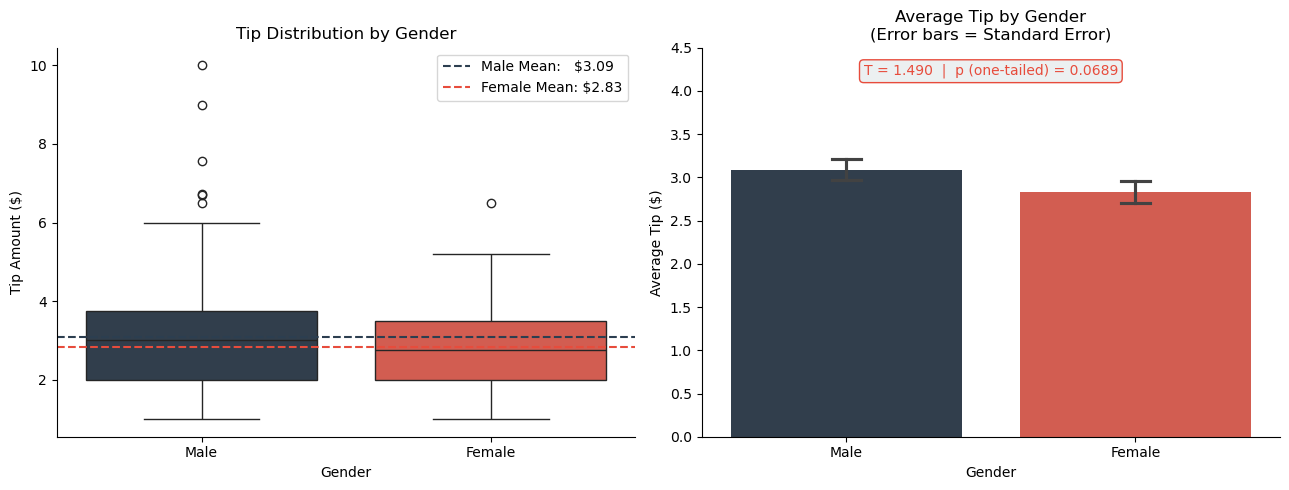

In [6]:
# Visualizing tip distributions and average tip amounts by gender
# Color scheme: navy (#2c3e50) for Male, red (#e74c3c) for Female
COLORS_T1 = {'Male': '#2c3e50', 'Female': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: Boxplot showing median, spread, and outliers for each gender group
sns.boxplot(data=tips, x='sex', y='tip', palette=COLORS_T1, ax=axes[0])
axes[0].set(title='Tip Distribution by Gender', xlabel='Gender', ylabel='Tip Amount ($)')
axes[0].axhline(male_tips.mean(),   color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Male Mean:   ${male_tips.mean():.2f}')
axes[0].axhline(female_tips.mean(), color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Female Mean: ${female_tips.mean():.2f}')
axes[0].legend(fontsize=10)

# Right plot: Bar chart of mean tips with standard error to show uncertainty around each mean
sns.barplot(data=tips, x='sex', y='tip', palette=COLORS_T1,
            capsize=0.1, errorbar='se', ax=axes[1])
axes[1].set(title='Average Tip by Gender\n(Error bars = Standard Error)',
            xlabel='Gender', ylabel='Average Tip ($)', ylim=(0, 4.5))
axes[1].text(0.5, 0.93, f'T = {t_stat:.3f}  |  p (one-tailed) = {p_value_one_tailed:.4f}',
             ha='center', transform=axes[1].transAxes, fontsize=10, color='#e74c3c',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#ecf0f1', edgecolor='#e74c3c'))

sns.despine()
plt.tight_layout()
plt.savefig('task1_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Interpret Results — Business Recommendation

**Statistical Finding:**  
The one-tailed t-test result indicates whether the difference in average tips (Male: ~\$3.09 vs. Female: ~\$2.83) is statistically significant. 

**Business Recommendation:**  
- If we **reject H₀**: The restaurant may consider scheduling more experienced servers during peak periods when male-dominated parties are more common, as the data suggests they tip more generously on average. However, management should avoid making staffing decisions **solely** on gender, as other factors like party size and total bill also play a role.  
- If we **fail to reject H₀**: Gender alone should **not** drive scheduling decisions. The restaurant should focus instead on factors like table size or time of day to optimize revenue.  

> **Note:** A statistically significant result does not always mean a *practically* significant result. The ~\$0.26 difference in average tips may not justify policy changes on its own.

---
## Task 2: The F-Test / ANOVA — Does Day of the Week Affect Total Bill?

### Step 1: Define Hypotheses

- **Null Hypothesis (H₀):** The **mean total bill is equal across all days** of the week.  
  → μ_Thur = μ_Fri = μ_Sat = μ_Sun

- **Alternative Hypothesis (H₁):** **At least one day** has a significantly different mean total bill.  
  → At least one μ_day ≠ others

> This is a **two-tailed / non-directional test** — we are testing if *any* day differs, not a specific direction.

### Step 2: Choose Significance Level
- **α = 0.05** — standard threshold.

### Step 3: Collect/Analyze Data
- **Independent variable (X):** `day` — Categorical (Thur, Fri, Sat, Sun)
- **Dependent variable (Y):** `total_bill` — Numerical (continuous)

In [7]:
# Filtering the dataset by day so we can compare spending across the four service days
thur_bills = tips[tips['day'] == 'Thur']['total_bill']
fri_bills  = tips[tips['day'] == 'Fri']['total_bill']
sat_bills  = tips[tips['day'] == 'Sat']['total_bill']
sun_bills  = tips[tips['day'] == 'Sun']['total_bill']

# Printing summary statistics to get a sense of the data before running the ANOVA
print("=== Summary Statistics: Total Bill by Day ===")
for day, data in [('Thursday', thur_bills), ('Friday', fri_bills),
                  ('Saturday', sat_bills),  ('Sunday', sun_bills)]:
    print(f"{day:10s} — Count: {len(data):3d}, Mean: ${data.mean():.2f}, Std: ${data.std():.2f}")

=== Summary Statistics: Total Bill by Day ===
Thursday   — Count:  62, Mean: $17.68, Std: $7.89
Friday     — Count:  19, Mean: $17.15, Std: $8.30
Saturday   — Count:  87, Mean: $20.44, Std: $9.48
Sunday     — Count:  76, Mean: $21.41, Std: $8.83


### Step 4: Calculate Test Statistic — Why ANOVA (F-Test)?

The **One-Way ANOVA (F-test)** is the correct choice here because:
- We are comparing the **means of more than two groups** (4 days: Thur, Fri, Sat, Sun).
- The outcome variable `total_bill` is **numerical and continuous**.
- A T-test can only compare **two groups** at a time — running multiple t-tests increases the risk of Type I errors (false positives).
- ANOVA tests all groups **simultaneously**, controlling for this inflated error rate.

The F-statistic = MSB / MSW (variance between groups / variance within groups). A large F → significant differences between day means.

In [8]:
# Running a one-way ANOVA across all four days simultaneously.
# This is preferred over multiple t-tests because it controls the overall Type I error rate.
f_stat, p_value_anova = stats.f_oneway(thur_bills, fri_bills, sat_bills, sun_bills)

print("=== One-Way ANOVA Results ===")
print(f"F-Statistic:        {f_stat:.4f}")
print(f"P-Value:            {p_value_anova:.4f}")
print(f"Significance Level: α = 0.05")

=== One-Way ANOVA Results ===
F-Statistic:        2.7675
P-Value:            0.0425
Significance Level: α = 0.05


In [9]:
# Deciding whether the variation in total bill across days is statistically significant
print("=== Decision ===")
if p_value_anova < alpha:
    print(f"p-value ({p_value_anova:.4f}) < α ({alpha})")
    print("→ REJECT H₀(Null Hypothesis): At least one day has a significantly different mean total bill.")
else:
    print(f"p-value ({p_value_anova:.4f}) ≥ α ({alpha})")
    print("→ FAIL TO REJECT H₀(Null Hypothesis): No significant difference in total bill across days.")

=== Decision ===
p-value (0.0425) < α (0.05)
→ REJECT H₀(Null Hypothesis): At least one day has a significantly different mean total bill.


C:\Users\DELL\AppData\Local\Temp\ipykernel_21100\465559647.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_means   = tips.groupby('day')['total_bill'].mean().reindex(day_order)
C:\Users\DELL\AppData\Local\Temp\ipykernel_21100\465559647.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill', order=day_order, palette=COLORS_T2, ax=axes[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_21100\465559647.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(day_labels)
C:\Users\DELL\AppData\Local\Temp\ipykernel_2

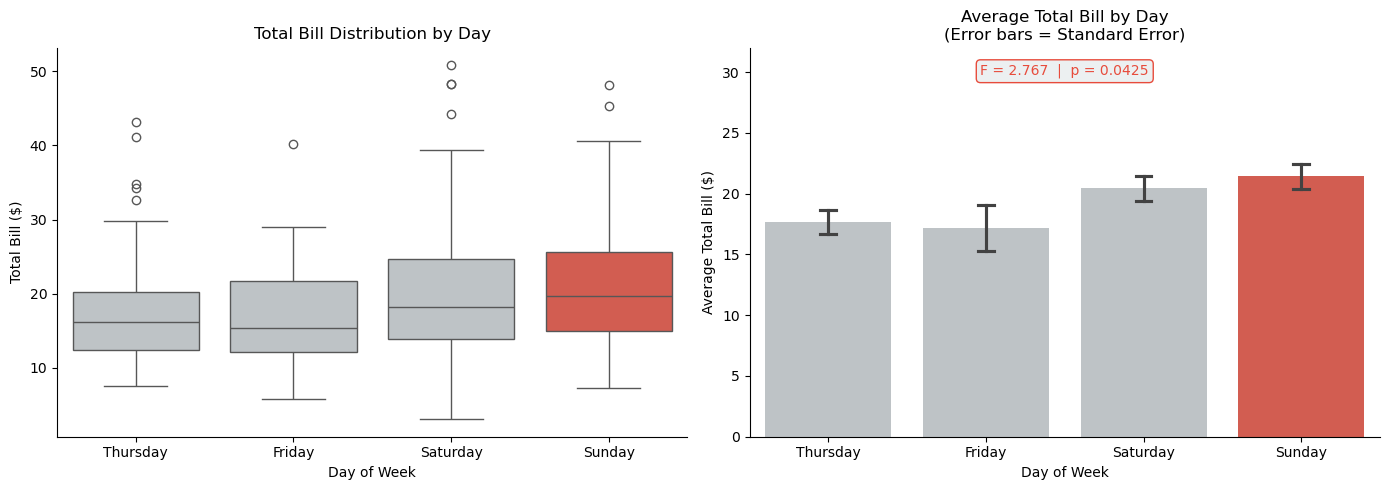

In [10]:
# Visualizing total bill distributions and daily averages across the four service days.
# The day with the highest average bill is highlighted in red; the rest stay grey.
day_order   = ['Thur', 'Fri', 'Sat', 'Sun']
day_labels  = ['Thursday', 'Friday', 'Saturday', 'Sunday']
day_means   = tips.groupby('day')['total_bill'].mean().reindex(day_order)
COLORS_T2   = ['#e74c3c' if d == day_means.idxmax() else '#bdc3c7' for d in day_order]

# Adding a readable label column so the bar chart x-axis shows full day names
tips['day_label'] = tips['day'].map(dict(zip(day_order, day_labels)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Boxplot showing the spread of bills for each day
sns.boxplot(data=tips, x='day', y='total_bill', order=day_order, palette=COLORS_T2, ax=axes[0])
axes[0].set(title='Total Bill Distribution by Day', xlabel='Day of Week', ylabel='Total Bill ($)')
axes[0].set_xticklabels(day_labels)

# Right plot: Mean bill per day with standard error bars to reflect uncertainty
sns.barplot(data=tips, x='day_label', y='total_bill', order=day_labels,
            palette=COLORS_T2, capsize=0.1, errorbar='se', ax=axes[1])
axes[1].set(title='Average Total Bill by Day\n(Error bars = Standard Error)',
            xlabel='Day of Week', ylabel='Average Total Bill ($)', ylim=(0, 32))
axes[1].text(0.5, 0.93, f'F = {f_stat:.3f}  |  p = {p_value_anova:.4f}',
             ha='center', transform=axes[1].transAxes, fontsize=10, color='#e74c3c',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#ecf0f1', edgecolor='#e74c3c'))

sns.despine()
plt.tight_layout()
plt.savefig('task2_anova.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Interpret Results — Business Recommendation

**Statistical Finding:**  
The One-Way ANOVA tests whether mean total bill differs significantly across the four days (Thursday, Friday, Saturday, Sunday).

**Business Recommendation:**  
- If we **reject H₀**: Spending patterns differ meaningfully by day. The restaurant should **allocate more staff and premium inventory** on higher-spending days (e.g., Saturday/Sunday) to maximize revenue and service quality. They could also run targeted promotions on lower-spending days (e.g., Friday) to boost average bill size.  
- If we **fail to reject H₀**: Day of the week does **not** significantly drive spending. Management should look at other factors (party size, time of day, menu items) to understand revenue variation.

> **Limitation:** ANOVA only tells us *that* a difference exists , it does not tell us *which* specific days differ. A post-hoc test (e.g., Tukey's HSD) would be needed for pairwise comparisons, which is beyond the scope of this assignment.

---
## Task 3: The Chi-Square Test — Is Smoking Independent of Dining Time?

### Step 1: Define Hypotheses

- **Null Hypothesis (H₀):** Smoking behavior and dining time are **independent** — the proportion of smokers does not differ between Lunch and Dinner.

- **Alternative Hypothesis (H₁):** Smoking behavior and dining time are **not independent** — the proportion of smokers differs between Lunch and Dinner.

> This is a **two-tailed / non-directional test** we test for any association, not a specific direction.

### Step 2: Choose Significance Level
- **α = 0.05** — standard threshold.

### Step 3: Collect/Analyze Data
- **Variable 1:** `smoker` — Categorical (Yes / No)
- **Variable 2:** `time` — Categorical (Lunch / Dinner)

We will create a **contingency table** (observed frequency table) of these two categorical variables.

In [11]:
# Building a contingency table to count how many smokers and non-smokers
# appear in each dining time period (Lunch vs. Dinner)
contingency_table = pd.crosstab(tips['smoker'], tips['time'])

print("=== Observed Contingency Table ===")
print(contingency_table)
print("\n=== Proportions by Time ===")
print(contingency_table.div(contingency_table.sum(axis=0), axis=1).round(3))

=== Observed Contingency Table ===
time    Lunch  Dinner
smoker               
Yes        23      70
No         45     106

=== Proportions by Time ===
time    Lunch  Dinner
smoker               
Yes     0.338   0.398
No      0.662   0.602


### Step 4: Calculate Test Statistic — Why Chi-Square?

The **Chi-square test of independence** is the correct choice here because:
- Both variables (`smoker` and `time`) are **categorical** (count/frequency data).
- We want to test whether there is an **association (relationship) between two categorical variables**.
- A T-test would be inappropriate — there is no numerical mean to compare.
- ANOVA would also be inappropriate — there are no continuous outcomes.

The χ² statistic measures how far the **observed counts** deviate from the **expected counts** (what we'd expect if smoking and time were truly independent).

In [12]:
# Running the chi-square test of independence.
# It returns the test statistic, p-value, degrees of freedom, and the expected
# frequencies we would see if there were truly no relationship between the two variables.
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

# Formatting the expected frequencies as a table for easy comparison with the observed counts
expected_df = pd.DataFrame(expected,
                            index=contingency_table.index,
                            columns=contingency_table.columns).round(2)

print("=== Chi-Square Test Results ===")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value:              {p_value_chi2:.4f}")
print(f"Degrees of Freedom:   {dof}")
print(f"Significance Level:   α = 0.05")

print("\n=== Expected Frequencies (under H₀) ===")
print(expected_df)

=== Chi-Square Test Results ===
Chi-Square Statistic: 0.5054
P-Value:              0.4771
Degrees of Freedom:   1
Significance Level:   α = 0.05

=== Expected Frequencies (under H₀) ===
time    Lunch  Dinner
smoker               
Yes     25.92   67.08
No      42.08  108.92


In [13]:
# Comparing the p-value to our threshold to determine if smoking and dining time are related
print("=== Decision ===")
if p_value_chi2 < alpha:
    print(f"p-value ({p_value_chi2:.4f}) < α ({alpha})")
    print("→ REJECT H₀(Null Hypothesis): Smoking behavior and dining time are NOT independent.")
    print("   There is a statistically significant association between smoking and meal time.")
else:
    print(f"p-value ({p_value_chi2:.4f}) ≥ α ({alpha})")
    print("→ FAIL TO REJECT H₀(Null Hypothesis): No significant association between smoking and dining time.")
    print("   Smoking behavior appears to be independent of whether customers dine at Lunch or Dinner.")

=== Decision ===
p-value (0.4771) ≥ α (0.05)
→ FAIL TO REJECT H₀(Null Hypothesis): No significant association between smoking and dining time.
   Smoking behavior appears to be independent of whether customers dine at Lunch or Dinner.


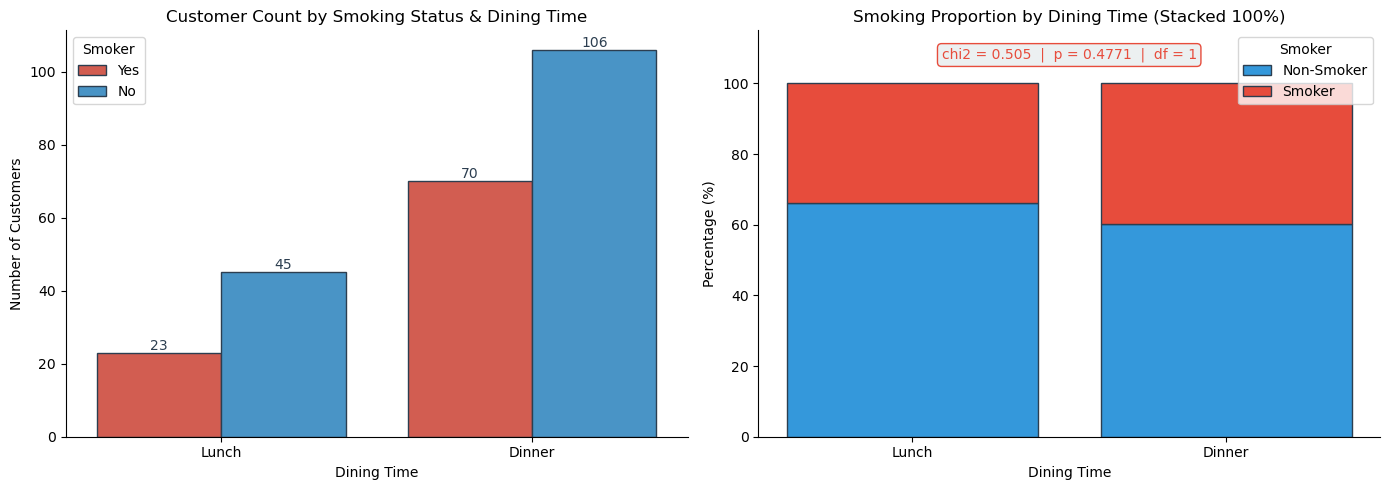

In [14]:
# Visualizing how smoking status is distributed across lunch and dinner service
# Blue (#3498db) = Non-Smoker, Red (#e74c3c) = Smoker
COLORS_T3 = {'No': '#3498db', 'Yes': '#e74c3c'}

# Reshaping the contingency table into long format so seaborn can work with it directly
ct_long    = contingency_table.reset_index().melt(id_vars='smoker', var_name='time', value_name='count')
prop_table = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100
prop_long  = prop_table.reset_index().melt(id_vars='smoker', var_name='time', value_name='pct')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Grouped bar chart showing raw customer counts per smoking group and dining time
sns.barplot(data=ct_long, x='time', y='count', hue='smoker',
            palette=COLORS_T3, edgecolor='#2c3e50', ax=axes[0])
axes[0].set(title='Customer Count by Smoking Status & Dining Time',
            xlabel='Dining Time', ylabel='Number of Customers')
axes[0].legend(title='Smoker')
for bar in axes[0].patches:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                     str(int(h)), ha='center', fontsize=10, color='#2c3e50')

# Right plot: Stacked 100% bar to show the proportional breakdown within each dining period
bot = prop_long[prop_long['smoker'] == 'No'].set_index('time')['pct']
top = prop_long[prop_long['smoker'] == 'Yes'].set_index('time')['pct']
axes[1].bar(bot.index, bot.values, color='#3498db', edgecolor='#2c3e50', label='Non-Smoker')
axes[1].bar(top.index, top.values, bottom=bot.values, color='#e74c3c', edgecolor='#2c3e50', label='Smoker')
axes[1].set(title='Smoking Proportion by Dining Time (Stacked 100%)',
            xlabel='Dining Time', ylabel='Percentage (%)', ylim=(0, 115))
axes[1].legend(title='Smoker')
axes[1].text(0.5, 0.93, f'chi2 = {chi2_stat:.3f}  |  p = {p_value_chi2:.4f}  |  df = {dof}',
             ha='center', transform=axes[1].transAxes, fontsize=10, color='#e74c3c',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#ecf0f1', edgecolor='#e74c3c'))

sns.despine()
plt.tight_layout()
plt.savefig('task3_chisquare.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Interpret Results — Business Recommendation

**Statistical Finding:**  
The Chi-square test checks whether smoking status and meal time (Lunch vs. Dinner) are statistically associated or whether they are independent.

**Business Recommendation:**  
- If we **reject H₀**: There is a meaningful difference in smoking behavior between Lunch and Dinner diners. The restaurant should ensure **designated smoking areas or ventilation systems** are appropriately staffed for whichever service has more smokers. Table assignments and seating policies could also be adjusted for guest comfort.  
- If we **fail to reject H₀**: Smoking patterns are consistent regardless of when customers dine. Management does **not** need to tailor smoking-related policies differently for Lunch vs. Dinner — a uniform policy across both services would be sufficient.

> **Note:** The Chi-square test is appropriate here because both variables are categorical (Smoker: Yes/No; Time: Lunch/Dinner). The test does not measure the *strength* of the association, only whether one exists.

---
## Summary of All Three Tests

| Task | Business Question | Test Used | Reason |
|------|-------------------|-----------|--------|
| 1 | Do males tip more than females? | **T-Test** | 2 groups, continuous outcome |
| 2 | Does day affect total bill? | **ANOVA (F-Test)** | 4 groups, continuous outcome |
| 3 | Is smoking independent of dining time? | **Chi-Square** | 2 categorical variables |

In [15]:
# Compiling the results from all three tests into a single summary table for easy comparison
summary = pd.DataFrame({
    'Task':             ['Task 1: T-Test',                  'Task 2: ANOVA',                      'Task 3: Chi-Square'],
    'Business Question':['Do males tip more than females?', 'Does day of week affect total bill?', 'Is smoking independent of dining time?'],
    'Test Used':        ['Welch T-Test',                    'One-Way ANOVA',                       'Chi-Square'],
    'Why This Test':    ['2 groups, continuous outcome',    '4 groups, continuous outcome',        '2 categorical variables'],
    'Test Statistic':   [f't = {t_stat:.4f}',              f'F = {f_stat:.4f}',                   f'chi2 = {chi2_stat:.4f}'],
    'P-Value':          [f'{p_value_one_tailed:.4f}',       f'{p_value_anova:.4f}',                f'{p_value_chi2:.4f}'],
    'alpha':            ['0.05',                            '0.05',                                '0.05'],
    'Decision':         [
        'Reject H0'   if p_value_one_tailed < 0.05 else 'Fail to Reject H0',
        'Reject H0'   if p_value_anova      < 0.05 else 'Fail to Reject H0',
        'Reject H0'   if p_value_chi2       < 0.05 else 'Fail to Reject H0'
    ]
})

print('=== Final Summary of All Hypothesis Tests ===')
display(summary)

=== Final Summary of All Hypothesis Tests ===


,Task,Business Question,Test Used,Why This Test,Test Statistic,P-Value,alpha,Decision
0,Task 1: T-Test,Do males tip more than females?,Welch T-Test,"2 groups, continuous outcome",t = 1.4895,0.0689,0.05,Fail to Reject H0
1,Task 2: ANOVA,Does day of week affect total bill?,One-Way ANOVA,"4 groups, continuous outcome",F = 2.7675,0.0425,0.05,Reject H0
2,Task 3: Chi-Square,Is smoking independent of dining time?,Chi-Square,2 categorical variables,chi2 = 0.5054,0.4771,0.05,Fail to Reject H0
